## Dataset Selection
I have selected the Airbnb dataset from Kaggle.

The dataset contains approximately 170000 records and 37 features.

I selected this dataset because it represents a real-world problem and contains both numerical and categorical features. It also contains missing values and variation in the data, making it suitable for performing EDA, dimensionality reduction and ensemble learning.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("Data/airbnb.csv")
df.head()

,id,name,price,property_type,room_type,accommodates,bathrooms,bedrooms,beds,city,...,number_of_reviews_ltm,number_of_reviews_l30d,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,206954,"Location, location! Awesome place in great area.",143.0,Entire rental unit,Entire home/apt,1,1.0,1.0,1.0,San Francisco,...,1,0,0.10,4.86,4.85,4.69,4.85,4.85,4.92,4.85
1,135896,[Navigli] Barbie Secret Caveau,71.0,Entire vacation home,Entire home/apt,5,1.0,1.0,3.0,Milan,...,4,1,0.56,4.92,4.75,4.92,4.92,4.92,4.75,4.75
2,30260,Modern Apartment on the beach,500.0,Entire rental unit,Entire home/apt,8,2.0,2.0,4.0,Broward County,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,82045,Deluxe beach studio,126.0,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,Lisbon,...,17,0,1.28,4.89,4.93,4.96,4.82,4.89,4.88,4.70
4,26272,"Superior Studio Apartment in Clifton, Bristol",94.0,Entire serviced apartment,Entire home/apt,2,1.0,0.0,1.0,Bristol,...,79,5,6.89,4.95,4.96,4.94,4.99,5.00,4.95,4.88


In [3]:
df.tail()

,id,name,price,property_type,room_type,accommodates,bathrooms,bedrooms,beds,city,...,number_of_reviews_ltm,number_of_reviews_l30d,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
169995,78294,Room @ Foxhollow House with Ensuite,73.0,Private room in bed and breakfast,Private room,2,1.0,1.0,1.0,Ireland,...,13,1,1.47,5.00,4.95,5.00,4.90,5.00,4.95,5.00
169996,152805,Sonder Battery Park | Accessible Queen Studio,194.0,Entire rental unit,Entire home/apt,2,1.0,0.0,1.0,New York City,...,5,1,0.92,4.52,4.54,4.68,4.50,4.36,4.64,4.56
169997,60054,Escorxador by Interhome,100.0,Entire rental unit,Entire home/apt,4,1.0,1.0,2.0,Girona,...,1,0,0.11,4.33,3.89,4.22,4.22,4.00,4.44,4.22
169998,259258,Roo with a View by Swan BnB Management,393.0,Entire home,Entire home/apt,6,1.0,3.0,4.0,Western Australia,...,5,1,1.35,5.00,4.60,4.80,5.00,4.60,5.00,4.80
169999,65268,Relaxing Waterfront Home,569.0,Entire home,Entire home/apt,6,2.0,3.0,4.0,Hawaii,...,6,0,0.63,5.00,5.00,5.00,4.83,4.83,5.00,4.67


In [4]:
df.shape

(170000, 37)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170000 entries, 0 to 169999
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           170000 non-null  int64  
 1   name                         170000 non-null  str    
 2   price                        170000 non-null  float64
 3   property_type                170000 non-null  str    
 4   room_type                    170000 non-null  str    
 5   accommodates                 170000 non-null  int64  
 6   bathrooms                    169922 non-null  float64
 7   bedrooms                     169765 non-null  float64
 8   beds                         169680 non-null  float64
 9   city                         170000 non-null  str    
 10  latitude                     170000 non-null  float64
 11  longitude                    170000 non-null  float64
 12  host_since                   169923 non-null  str    
 13  host_respo

In [6]:
num = df.select_dtypes(include="number")
num.columns

Index(['id', 'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'latitude', 'longitude', 'host_listings_count',
       'host_total_listings_count', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'reviews_per_month',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value'],
      dtype='str')

In [7]:
num.describe().T

,count,mean,std,min,25%,50%,75%,max
id,170000.0,130914.250971,75624.558908,1.00000,65453.750000,130891.000000,196445.250000,261893.000000
price,170000.0,207.306259,197.460789,1.00000,81.000000,136.000000,250.000000,1000.000000
accommodates,170000.0,3.947365,2.439292,1.00000,2.000000,4.000000,5.000000,16.000000
bathrooms,169922.0,1.392433,0.794236,0.00000,1.000000,1.000000,2.000000,50.000000
bedrooms,169765.0,1.647542,1.137280,0.00000,1.000000,1.000000,2.000000,50.000000
beds,169680.0,2.332349,1.830980,0.00000,1.000000,2.000000,3.000000,121.000000
latitude,170000.0,32.571646,24.553433,-43.44011,34.104338,40.145580,45.691549,60.025359
longitude,170000.0,-12.990166,71.549928,-159.71428,-73.958773,2.159201,14.776405,153.634660
host_listings_count,169923.0,75.529699,412.945890,0.00000,1.000000,3.000000,15.000000,5282.000000
host_total_listings_count,169923.0,112.065041,582.721934,0.00000,2.000000,4.000000,20.000000,9988.000000


In [8]:
cat = df.select_dtypes(include="object")
cat.columns

C:\Users\acer\AppData\Local\Temp\ipykernel_6140\960420706.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include="object")


Index(['name', 'property_type', 'room_type', 'city', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
       'has_availability'],
      dtype='str')

In [9]:
cat.describe(include="object").T

C:\Users\acer\AppData\Local\Temp\ipykernel_6140\4236060157.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat.describe(include="object").T


,count,unique,top,freq
name,170000,167027,Home away from home,34
property_type,170000,135,Entire rental unit,69166
room_type,170000,4,Entire home/apt,132688
city,170000,108,London,10961
host_since,169923,5552,2016-12-16,751
host_response_time,143965,4,within an hour,108958
host_response_rate,143965,100,100%,111841
host_acceptance_rate,155322,101,100%,65710
host_is_superhost,165249,2,f,107760
host_has_profile_pic,169923,2,t,162653


In [10]:
df.isnull().sum()

id                                 0
name                               0
price                              0
property_type                      0
room_type                          0
accommodates                       0
bathrooms                         78
bedrooms                         235
beds                             320
city                               0
latitude                           0
longitude                          0
host_since                        77
host_response_time             26035
host_response_rate             26035
host_acceptance_rate           14678
host_is_superhost               4751
host_listings_count               77
host_total_listings_count         77
host_has_profile_pic              77
host_identity_verified            77
has_availability                1472
availability_30                    0
availability_60                    0
availability_90                    0
availability_365                   0
number_of_reviews                  0
n

In [11]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct

review_scores_checkin          19.511765
review_scores_value            19.511176
review_scores_location         19.510588
review_scores_cleanliness      19.508824
review_scores_communication    19.508824
review_scores_accuracy         19.508235
review_scores_rating           19.505882
reviews_per_month              19.505294
host_response_rate             15.314706
host_response_time             15.314706
host_acceptance_rate            8.634118
host_is_superhost               2.794706
has_availability                0.865882
beds                            0.188235
bedrooms                        0.138235
bathrooms                       0.045882
host_since                      0.045294
host_identity_verified          0.045294
host_has_profile_pic            0.045294
host_total_listings_count       0.045294
host_listings_count             0.045294
room_type                       0.000000
property_type                   0.000000
price                           0.000000
name            

<Axes: ylabel='None'>

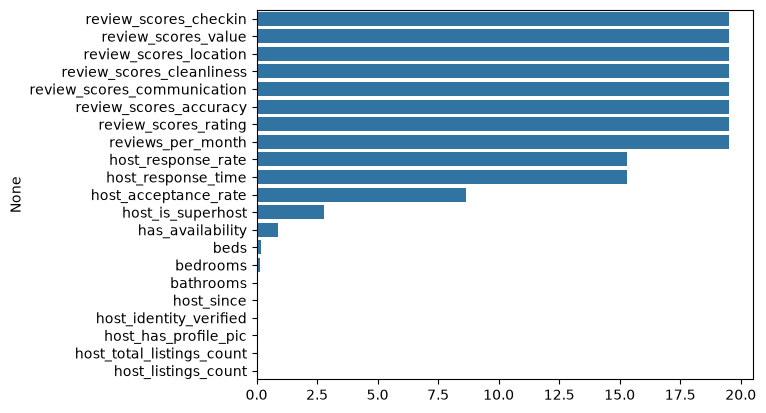

In [12]:
sns.barplot(x=missing_pct.head(21).values, y=missing_pct.head(21).index)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["id"].duplicated().sum()

np.int64(0)

In [15]:
df["id"].nunique()

170000

In [16]:
num = df.select_dtypes(include="number")
num.columns

Index(['id', 'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'latitude', 'longitude', 'host_listings_count',
       'host_total_listings_count', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'reviews_per_month',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value'],
      dtype='str')

## Target Analysis

In [17]:
df["price"].describe()

count    170000.000000
mean        207.306259
std         197.460789
min           1.000000
25%          81.000000
50%         136.000000
75%         250.000000
max        1000.000000
Name: price, dtype: float64

In [18]:
df["price"].isna().sum()

np.int64(0)

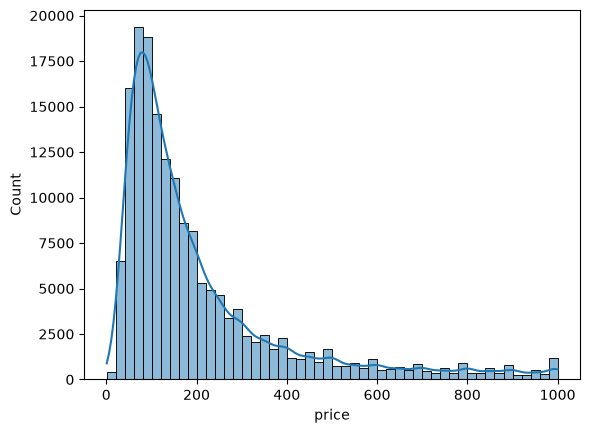

In [19]:
sns.histplot(df["price"], bins=50, kde="True")
plt.show()

In [20]:
df["price"].skew()

np.float64(2.045973536996614)

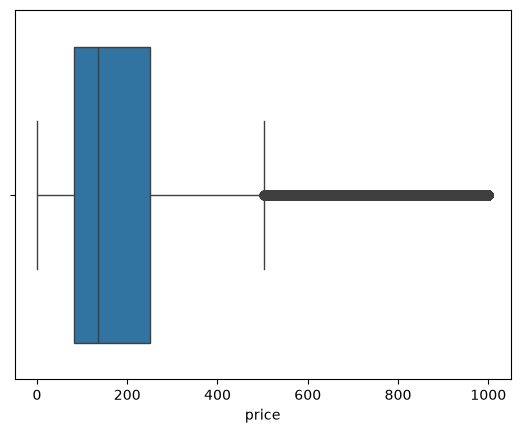

In [21]:
sns.boxplot(x=df["price"])
plt.show()

In [22]:
Q1 = df["price"].quantile(.25)
Q3 = df["price"].quantile(.75)

In [23]:
IQR = Q3 - Q1

In [24]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [25]:
((df.price < lower) | (df.price > upper)).sum()

np.int64(14831)

#### The price distribution is strongly right-skewed and the IQR method identifies many high-price observations as outliers. These values were not removed automatically because they may represent genuine high-priced listings rather than incorrect records.

## Analyze room_type

In [26]:
df["room_type"].value_counts()

room_type
Entire home/apt    132688
Private room        35675
Hotel room            977
Shared room           660
Name: count, dtype: int64

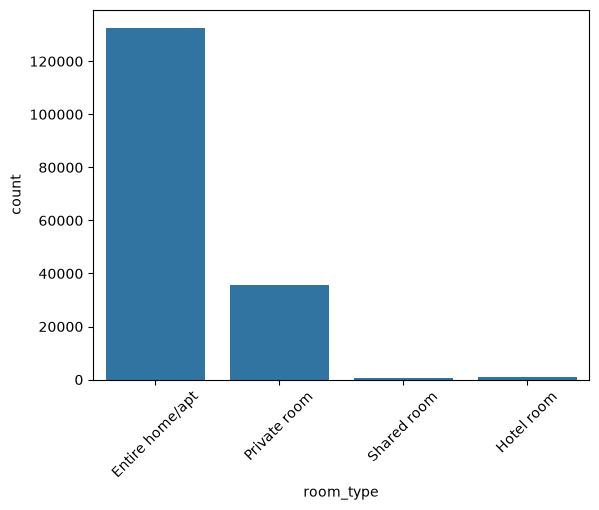

In [27]:
sns.countplot(data=df, x="room_type")
plt.xticks(rotation=45)
plt.show()

In [28]:
df.groupby("room_type")["price"].median()

room_type
Entire home/apt    152.0
Hotel room         220.0
Private room        79.0
Shared room         43.0
Name: price, dtype: float64

## Analyze property_type

In [29]:
df["property_type"].nunique()

135

In [30]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   69166
Entire home                          25856
Entire condo                         14101
Private room in rental unit          12389
Private room in home                 10513
Entire villa                          4354
Private room in bed and breakfast     3171
Room in hotel                         2536
Entire serviced apartment             2530
Entire guest suite                    2412
Entire guesthouse                     2317
Private room in condo                 2064
Entire townhouse                      2051
Entire vacation home                  1701
Entire loft                           1629
Name: count, dtype: int64

In [31]:
df.groupby("property_type")["price"].median().nlargest(15)

property_type
Hotel room                       899.0
Plane                            680.0
Entire in-law                    650.0
Entire hostel                    643.0
Private room in minsu            398.0
Shared room in aparthotel        394.0
Riad                             358.0
Private room in ryokan           333.0
Private room in resort           326.0
Private room in kezhan           299.5
Shared room in boutique hotel    293.5
Room in resort                   291.0
Entire villa                     279.0
Shipping container               266.0
Religious building               260.5
Name: price, dtype: float64

In [32]:
prop = df["property_type"].value_counts()
prop

property_type
Entire rental unit             69166
Entire home                    25856
Entire condo                   14101
Private room in rental unit    12389
Private room in home           10513
                               ...  
Lighthouse                         1
Shared room in nature lodge        1
Shared room                        1
Private room in windmill           1
Room in rental unit                1
Name: count, Length: 135, dtype: int64

## Analyze city

In [33]:
df["city"].value_counts()

city
London            10961
Paris             10381
Sicily             8942
Puglia             6987
Los Angeles        6114
                  ...  
Bozeman              90
Albany               71
Barossa Valley       56
Salem, OR            48
Pacific Grove        46
Name: count, Length: 108, dtype: int64

In [34]:
df.groupby("city")["price"].median()

city
Albany                96.0
Amsterdam            200.0
Antwerp              100.0
Asheville            125.0
Athens                70.0
                     ...  
Victoria             137.5
Vienna                81.0
Washington, D.C      131.0
Western Australia    251.5
Winnipeg              93.5
Name: price, Length: 108, dtype: float64

In [35]:
top_cities = df["city"].value_counts().head(10)
top_cities

city
London            10961
Paris             10381
Sicily             8942
Puglia             6987
Los Angeles        6114
Hawaii             5217
South Aegean       4818
Rio de Janeiro     4529
Crete              3934
New York City      3833
Name: count, dtype: int64

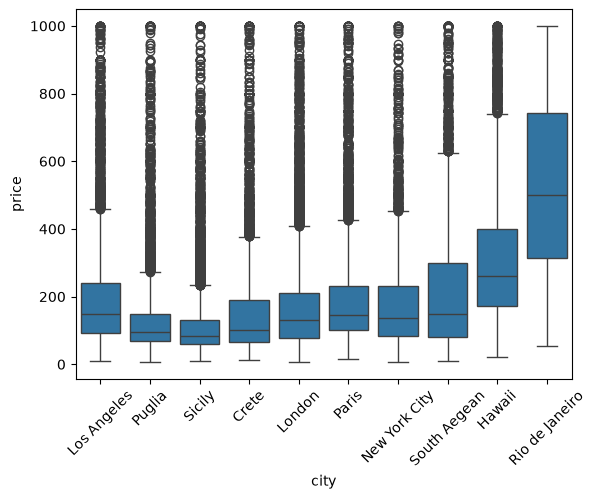

In [36]:
sns.boxplot(data=df[df["city"].isin(top_cities.index)], x="city", y="price")
plt.xticks(rotation=45)
plt.show()

In [37]:
df.groupby("accommodates")["price"].median()

accommodates
1      60.0
2     100.0
3     112.0
4     141.0
5     155.0
6     208.0
7     223.0
8     290.0
9     294.0
10    340.0
11    342.0
12    374.0
13    397.0
14    446.0
15    425.5
16    468.0
Name: price, dtype: float64

In [38]:
price_acc = df.groupby("accommodates")["price"].median()

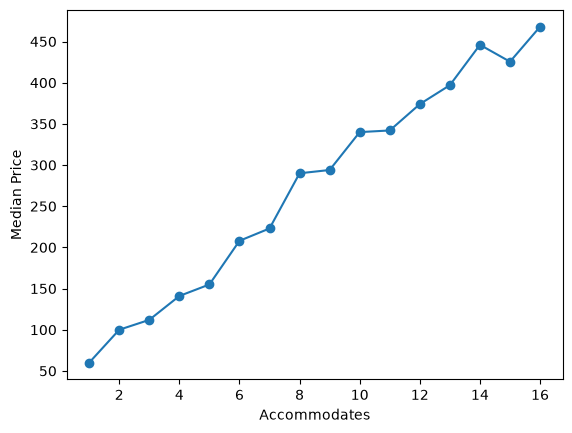

In [39]:
price_acc.plot(kind="line",marker="o")

plt.xlabel("Accommodates")
plt.ylabel("Median Price")
plt.show()

## Bedrooms, Bathrooms and Beds

In [40]:
cols = ["bedrooms", "bathrooms", "beds"]
df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bedrooms,169765.0,1.647542,1.137280,0.0,1.0,1.0,2.0,50.0
bathrooms,169922.0,1.392433,0.794236,0.0,1.0,1.0,2.0,50.0
beds,169680.0,2.332349,1.830980,0.0,1.0,2.0,3.0,121.0


In [41]:
df.groupby("bedrooms")["price"].median()

bedrooms
0.0     105.0
1.0     101.0
2.0     161.0
3.0     227.0
4.0     318.0
5.0     390.0
6.0     475.0
7.0     502.0
8.0     470.0
9.0     550.0
10.0    499.0
11.0    184.5
12.0    624.0
13.0    120.0
14.0    101.0
15.0    243.0
16.0    177.0
17.0    531.0
18.0    472.5
20.0     65.5
25.0    335.0
27.0     70.0
40.0     20.0
41.0    100.0
50.0     89.0
Name: price, dtype: float64

In [42]:
df.groupby("bathrooms")["price"].median()

bathrooms
0.0      106.0
0.5       75.0
1.0      114.0
1.5      125.0
2.0      213.0
2.5      259.0
3.0      308.0
3.5      382.0
4.0      390.0
4.5      442.0
5.0      446.0
5.5      520.0
6.0      485.5
6.5      550.0
7.0      519.0
7.5      561.0
8.0      332.0
8.5      680.0
9.0      497.0
9.5      691.5
10.0      65.0
10.5    1000.0
11.0      46.5
11.5     153.0
12.0      80.0
14.0     100.0
16.0     200.0
17.0     971.0
20.0     397.5
25.0     600.0
26.0     211.0
27.0      70.0
33.0      20.0
50.0     550.0
Name: price, dtype: float64

In [43]:
df.groupby("beds")["price"].median()

beds
0.0      120.0
1.0       99.0
2.0      134.0
3.0      170.0
4.0      202.0
5.0      238.0
6.0      275.0
7.0      312.5
8.0      330.0
9.0      363.0
10.0     391.0
11.0     423.0
12.0     390.0
13.0     501.0
14.0     463.0
15.0     445.0
16.0     334.0
17.0     551.5
18.0     473.0
19.0     735.0
20.0     389.5
21.0     499.0
22.0     495.5
23.0     104.5
24.0     634.0
25.0     226.5
26.0     176.0
27.0     624.0
28.0     154.5
29.0     971.0
30.0      69.0
33.0     949.0
34.0     886.0
35.0     750.0
38.0     124.0
41.0     105.0
46.0      64.0
50.0     440.0
121.0     20.0
Name: price, dtype: float64

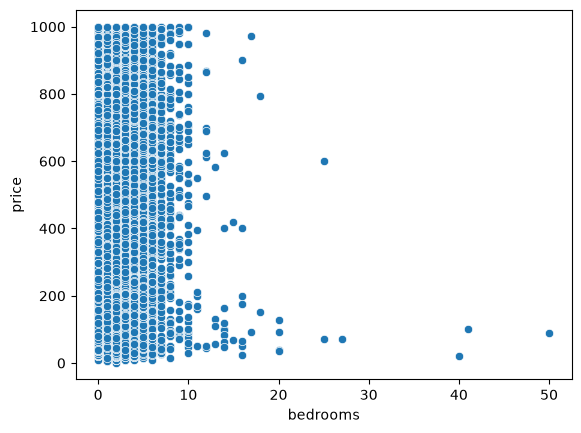

In [44]:
sns.scatterplot(data=df, x="bedrooms", y="price")
plt.show()

## Host Analysis

In [45]:
df["host_is_superhost"].value_counts()

host_is_superhost
f    107760
t     57489
Name: count, dtype: int64

In [46]:
df.groupby("host_is_superhost")["price"].median()

host_is_superhost
f    132.0
t    143.0
Name: price, dtype: float64

In [47]:
df["host_response_time"].value_counts()

host_response_time
within an hour        108958
within a few hours     18512
within a day           11597
a few days or more      4898
Name: count, dtype: int64

In [48]:
df["host_listings_count"].describe()

count    169923.000000
mean         75.529699
std         412.945890
min           0.000000
25%           1.000000
50%           3.000000
75%          15.000000
max        5282.000000
Name: host_listings_count, dtype: float64

## Review Analysis

In [49]:
review_cols = ["number_of_reviews", "reviews_per_month","review_scores_rating"]

In [50]:
df[review_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_reviews,170000.0,42.517388,85.524234,0.00,1.00,10.00,44.0,3117.0
reviews_per_month,136841.0,1.436927,1.743756,0.01,0.30,0.85,2.0,82.6
review_scores_rating,136840.0,4.749155,0.393447,0.00,4.67,4.86,5.0,5.0


In [51]:
df[review_cols + ["price"]].corr()["price"]

number_of_reviews      -0.078022
reviews_per_month      -0.073211
review_scores_rating    0.060251
price                   1.000000
Name: price, dtype: float64

## Review Score Analysis

In [52]:
score_cols = ["review_scores_rating", "review_scores_cleanliness", "review_scores_location", "review_scores_value"]

In [53]:
df[score_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
review_scores_rating,136840.0,4.749155,0.393447,0.0,4.67,4.86,5.00,5.0
review_scores_cleanliness,136835.0,4.739975,0.403365,0.0,4.67,4.86,5.00,5.0
review_scores_location,136832.0,4.777165,0.334608,0.0,4.70,4.88,5.00,5.0
review_scores_value,136831.0,4.662857,0.424446,0.0,4.57,4.77,4.91,5.0


In [54]:
df[score_cols + ["price"]].corr()["price"]

review_scores_rating         0.060251
review_scores_cleanliness    0.035691
review_scores_location       0.094274
review_scores_value          0.031897
price                        1.000000
Name: price, dtype: float64

### Review-related variables show relatively weak linear correlation with price.

## Availability Analysis

In [55]:
avail = ["availability_30", "availability_60", "availability_90", "availability_365"]

In [56]:
df[avail].describe().T

,count,mean,std,min,25%,50%,75%,max
availability_30,170000.0,14.722294,11.322435,0.0,2.0,15.0,26.0,30.0
availability_60,170000.0,32.967176,22.227937,0.0,11.0,37.0,55.0,60.0
availability_90,170000.0,52.914994,32.651645,0.0,23.0,61.0,84.0,90.0
availability_365,170000.0,212.188024,119.829089,0.0,101.0,233.0,329.0,365.0


In [57]:
df[avail + ["price"]].corr()["price"]

availability_30    -0.020262
availability_60    -0.011775
availability_90    -0.009251
availability_365    0.007151
price               1.000000
Name: price, dtype: float64

### The availability variables shows strong multicollinearity, particularly availability_60 and availability_90.

## Host Rate Analysis

In [58]:
df["host_response_rate"].head()

0    100%
1    100%
2    100%
3    100%
4    100%
Name: host_response_rate, dtype: str

In [59]:
df["host_acceptance_rate"].head()

0     96%
1     83%
2    100%
3    100%
4    100%
Name: host_acceptance_rate, dtype: str

## Date Analysis

In [60]:
df["host_since"].head()

0    2013-01-13
1    2017-02-16
2    2017-02-11
3    2016-01-21
4    2020-02-11
Name: host_since, dtype: str

In [61]:
df["host_since"] = pd.to_datetime(df["host_since"])

In [62]:
df["host_year"] = df["host_since"].dt.year

In [63]:
num = df.select_dtypes(include="number")

In [64]:
df.groupby("host_year")["price"].median()

host_year
2008.0    116.0
2009.0    172.0
2010.0    134.5
2011.0    140.0
2012.0    140.0
2013.0    144.0
2014.0    141.0
2015.0    144.0
2016.0    147.0
2017.0    140.0
2018.0    130.0
2019.0    129.0
2020.0    140.0
2021.0    136.0
2022.0    134.0
2023.0    125.0
2024.0    120.0
2025.0    112.0
Name: price, dtype: float64

## Numerical Correlation

In [65]:
corr = num.corr()

In [66]:
corr["price"].sort_values()

latitude                      -0.302982
number_of_reviews             -0.078022
number_of_reviews_ltm         -0.073755
reviews_per_month             -0.073211
number_of_reviews_l30d        -0.039653
host_year                     -0.033846
id                            -0.021093
availability_30               -0.020262
availability_60               -0.011775
availability_90               -0.009251
availability_365               0.007151
longitude                      0.013807
review_scores_communication    0.024953
review_scores_value            0.031897
review_scores_checkin          0.033752
review_scores_cleanliness      0.035691
review_scores_accuracy         0.041043
host_listings_count            0.049377
host_total_listings_count      0.056636
review_scores_rating           0.060251
review_scores_location         0.094274
beds                           0.251645
bathrooms                      0.298193
bedrooms                       0.306822
accommodates                   0.323136


In [67]:
corr["price"].abs().sort_values(ascending=False)

price                          1.000000
accommodates                   0.323136
bedrooms                       0.306822
latitude                       0.302982
bathrooms                      0.298193
beds                           0.251645
review_scores_location         0.094274
number_of_reviews              0.078022
number_of_reviews_ltm          0.073755
reviews_per_month              0.073211
review_scores_rating           0.060251
host_total_listings_count      0.056636
host_listings_count            0.049377
review_scores_accuracy         0.041043
number_of_reviews_l30d         0.039653
review_scores_cleanliness      0.035691
host_year                      0.033846
review_scores_checkin          0.033752
review_scores_value            0.031897
review_scores_communication    0.024953
id                             0.021093
availability_30                0.020262
longitude                      0.013807
availability_60                0.011775
availability_90                0.009251


## Correlation Heatmap

In [68]:
top = corr["price"].abs()

In [69]:
top = top.nlargest(12).index

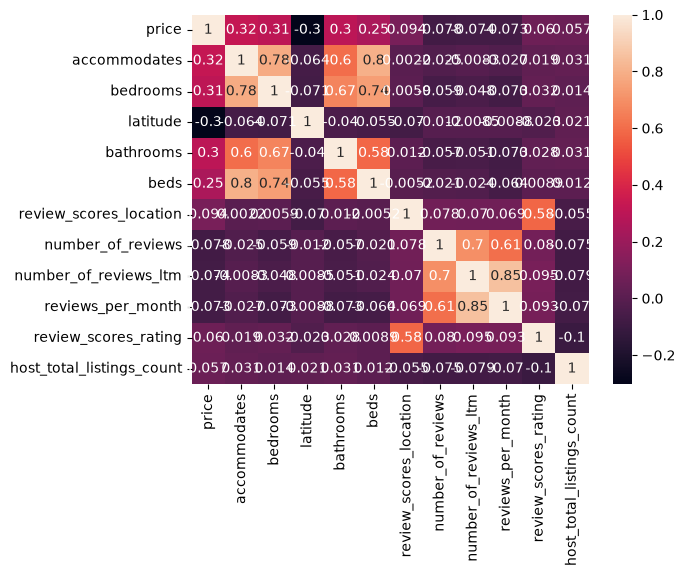

In [70]:
sns.heatmap(df[top].corr(),annot=True)
plt.show()

## Check Multicollinearity

In [71]:
df[["accommodates", "bedrooms", "beds"]].corr()

,accommodates,bedrooms,beds
accommodates,1.000000,0.782730,0.796561
bedrooms,0.782730,1.000000,0.744617
beds,0.796561,0.744617,1.000000


In [72]:
df[["availability_30", "availability_60", "availability_90", "availability_365"]].corr()

,availability_30,availability_60,availability_90,availability_365
availability_30,1.000000,0.929022,0.86446,0.467756
availability_60,0.929022,1.000000,0.97015,0.537009
availability_90,0.864460,0.970150,1.00000,0.587830
availability_365,0.467756,0.537009,0.58783,1.000000


## Categorical Feature

In [73]:
cat.nunique().sort_values(ascending=False)

name                      167027
host_since                  5552
property_type                135
city                         108
host_acceptance_rate         101
host_response_rate           100
room_type                      4
host_response_time             4
host_is_superhost              2
host_has_profile_pic           2
host_identity_verified         2
has_availability               2
dtype: int64

In [74]:
df["name"].nunique()

167027

## Check Important Categorical Features

In [75]:
categorical_cols = ["room_type","property_type","city","host_response_time"]

In [76]:
df["room_type"].nunique()

4

In [77]:
df["property_type"].nunique()

135

In [78]:
df["city"].nunique()

108

In [79]:
df["host_response_time"].nunique()

4

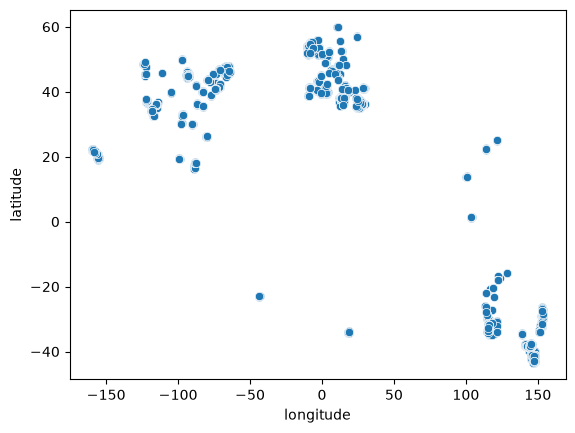

In [80]:
sns.scatterplot(data=df, x="longitude", y="latitude")
plt.show()

In [81]:
df[["latitude", "longitude", "price"]].corr()

,latitude,longitude,price
latitude,1.000000,-0.445477,-0.302982
longitude,-0.445477,1.000000,0.013807
price,-0.302982,0.013807,1.000000


## EDA Findings

- The target variable price is highly/right skewed.
- The dataset contains missing values in several features.
- Price varies across room types and property types.
- Accommodation-related features show relationships with price.
- Review and host-related features may contribute to price prediction.
- Several availability features are highly related to each other.
- High-cardinality columns such as name are unsuitable for direct encoding.
- id and name will be removed before model training.
- Categorical variables require encoding.
- Numerical variables require appropriate missing-value treatment.

## Data Preparation for Machine Learning

The target variable is `price`, so this is a regression problem. I will prepare the features, split the data into training and testing sets, and then apply preprocessing.

In [82]:
data = df.copy()

data.drop(columns=["id", "name"], inplace=True)

In [83]:
rate_cols = ["host_response_rate", "host_acceptance_rate"]

for col in rate_cols:
    data[col] = data[col].str.replace("%", "").astype(float)

In [84]:
data["host_since"] = pd.to_datetime(data["host_since"])
data["host_year"] = data["host_since"].dt.year

data.drop(columns="host_since", inplace=True)

## Feature Engineering

I created `host_year` from `host_since` to capture the year in which the host joined the platform.

In [85]:
data["bedrooms_per_guest"] = data["bedrooms"] / data["accommodates"]
data["beds_per_guest"] = data["beds"] / data["accommodates"]

In [86]:
data[["host_year", "bedrooms_per_guest", "beds_per_guest"]].head()

,host_year,bedrooms_per_guest,beds_per_guest
0,2013.0,1.00,1.0
1,2017.0,0.20,0.6
2,2017.0,0.25,0.5
3,2016.0,0.50,0.5
4,2020.0,0.00,0.5


### Feature Engineering Insight

`bedrooms_per_guest` and `beds_per_guest` represent the available sleeping capacity relative to the number of guests a property accommodates. These features may provide additional information about property size and layout.

In [87]:
X = data.drop(columns="price")
y = data["price"]

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
print(X_train.shape)
print(X_test.shape)

(136000, 36)
(34000, 36)


In [90]:
num_cols = X_train.select_dtypes(include="number").columns
for col in num_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

In [91]:
cat_cols = X_train.select_dtypes(include="object").columns
X_train[cat_cols] = X_train[cat_cols].fillna("Unknown")
X_test[cat_cols] = X_test[cat_cols].fillna("Unknown")

C:\Users\acer\AppData\Local\Temp\ipykernel_6140\2241121841.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns


In [92]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


# Part 2: Principal Component Analysis (PCA)

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [94]:
pca_cols = X_train.select_dtypes(include="number").columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[pca_cols])
X_test_scaled = scaler.transform(X_test[pca_cols])

In [95]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

In [96]:
variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(variance >= 0.95) + 1
print("Components required for 95% variance:", n_components)

Components required for 95% variance: 18


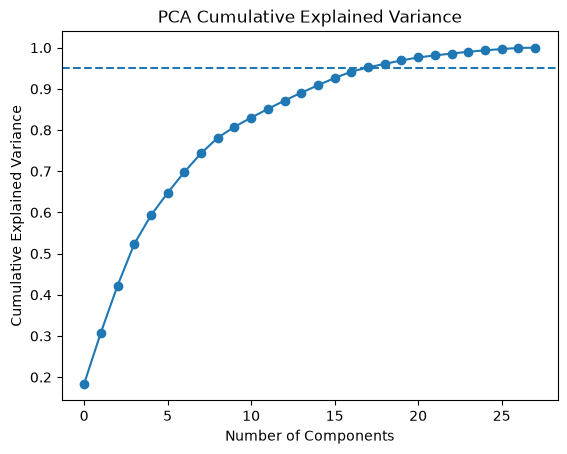

In [97]:
plt.plot(variance, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()

## PCA Interpretation

A principal component is a new variable created as a combination of the original numerical features.

The first principal component captures the largest amount of variation in the data. Each following component captures additional variation while being independent of the previous components.

### PCA Decision for Ensemble Models

I used PCA for dimensionality-reduction analysis, but I will use the original encoded features for ensemble training. This allows the models to retain the information contained in the categorical variables as well as the numerical variables.

In [98]:
X_train = pd.get_dummies(X_train,columns=cat_cols,dtype=int)
X_test = pd.get_dummies(X_test,columns=cat_cols,dtype=int)

In [99]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [100]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(136000, 287)
(34000, 287)
True


# Part 3: Unsupervised Learning

## K-Means Clustering

K-Means groups observations into a predefined number of clusters. It starts with centroids, assigns each observation to the closest centroid, updates the centroids, and repeats the process until the clusters become stable.

The number of clusters can be explored using the Elbow Method.

## DBSCAN

# Part 4: Ensemble Learning

### Problem Type: Regression

The target variable is `price`, which is a continuous numerical value. Therefore, this is a regression problem.

I will compare Random Forest, AdaBoost and XGBoost using the same training and testing data.

## Random Forest

In [104]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, max_features=0.8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y, pred):
    mae = mean_absolute_error(y, pred)
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)

    return mae, mse, rmse, r2

In [106]:
rf_mae, rf_mse, rf_rmse, rf_r2 = evaluate(y_test, rf_pred)

print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 66.32089626936295
MSE: 11749.244562009986
RMSE: 108.3939323117765
R2: 0.69437533188937


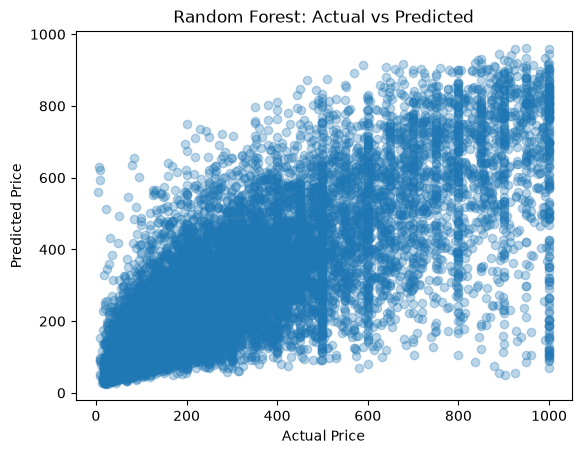

In [107]:
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

### Random Forest: Actual vs Predicted
From the plot, I can see that the predicted price generally increases when the actual price increases. This shows that the model has learned the overall pattern in the data.

However, the points are quite spread out, especially for expensive listings. So, the model is not predicting every listing accurately and has more difficulty with some higher-priced properties.

## AdaBoost

In [108]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(n_estimators=200, learning_rate=0.03, random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

In [109]:
ada_mae, ada_mse, ada_rmse, ada_r2 = evaluate(y_test, ada_pred)

print("MAE:", ada_mae)
print("MSE:", ada_mse)
print("RMSE:", ada_rmse)
print("R2:", ada_r2)

MAE: 129.524418601634
MSE: 26267.25549400853
RMSE: 162.07176032242177
R2: 0.3167287309270107


## XGBoost

In [110]:
from xgboost import XGBRegressor

In [111]:
xgb = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, random_state=42,n_jobs=-1,tree_method="hist")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [112]:
xgb_mae, xgb_mse, xgb_rmse, xgb_r2 = evaluate(y_test, xgb_pred)

print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

MAE: 69.46848583410592
MSE: 12524.01404793118
RMSE: 111.91074143231819
R2: 0.6742218091886389


In [113]:
results = pd.DataFrame({"Model": ["Random Forest", "AdaBoost", "XGBoost"],
                        "MAE": [rf_mae, ada_mae, xgb_mae],
                        "MSE": [rf_mse, ada_mse, xgb_mse],
                        "RMSE": [rf_rmse, ada_rmse, xgb_rmse],
                        "R2": [rf_r2, ada_r2, xgb_r2]
})
results

,Model,MAE,MSE,RMSE,R2
0,Random Forest,66.320896,11749.244562,108.393932,0.694375
1,AdaBoost,129.524419,26267.255494,162.071760,0.316729
2,XGBoost,69.468486,12524.014048,111.910741,0.674222


In [114]:
results.sort_values("RMSE")

,Model,MAE,MSE,RMSE,R2
0,Random Forest,66.320896,11749.244562,108.393932,0.694375
2,XGBoost,69.468486,12524.014048,111.910741,0.674222
1,AdaBoost,129.524419,26267.255494,162.071760,0.316729


### Hyperparameter Tuning Observation

After changing a few hyperparameters, the Random Forest R² increased from 0.687 to 0.694 and its RMSE also decreased. XGBoost also improved compared with its earlier result.

AdaBoost did not improve with these changes and its performance became slightly worse.

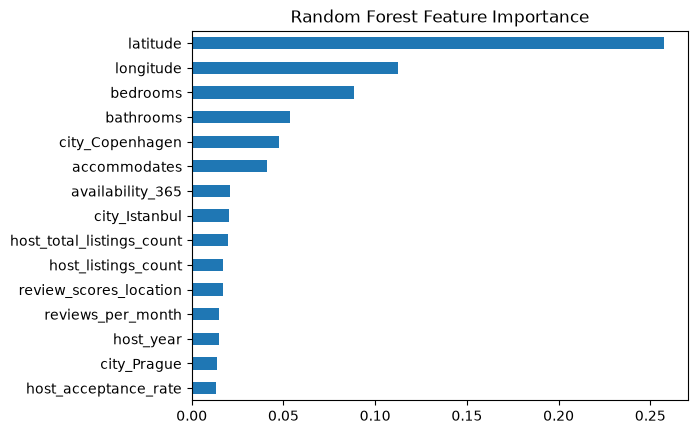

In [115]:
rf_importance = pd.Series(rf.feature_importances_,index=X_train.columns).nlargest(15)
rf_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

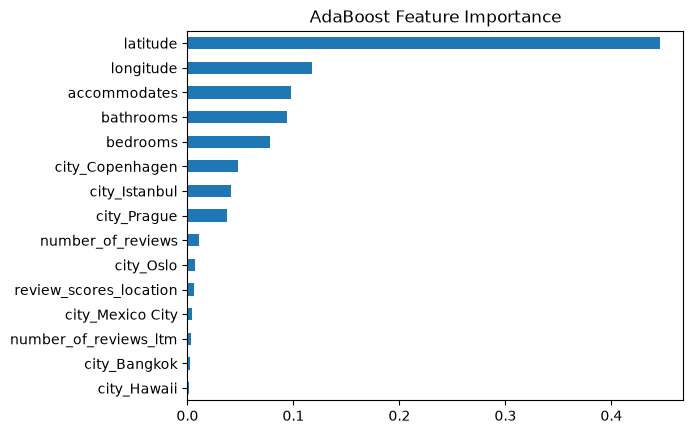

In [116]:
ada_importance = pd.Series(ada.feature_importances_, index=X_train.columns).nlargest(15)
ada_importance.sort_values().plot(kind="barh")
plt.title("AdaBoost Feature Importance")
plt.show()

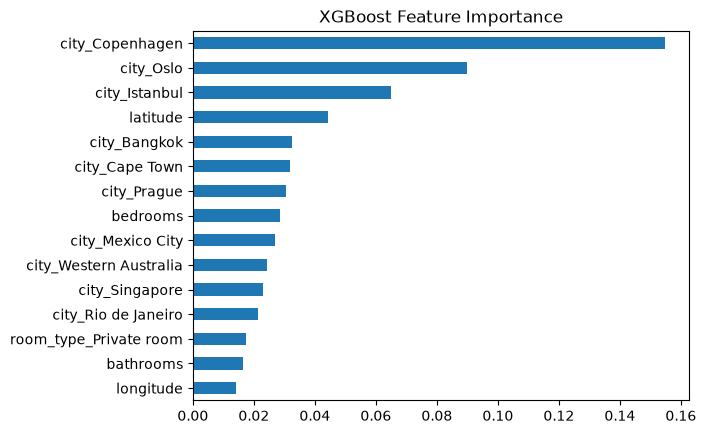

In [117]:
xgb_importance = pd.Series(xgb.feature_importances_,index=X_train.columns).nlargest(15)
xgb_importance.sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.show()

## Feature Importance


### Feature Importance Observation

The Random Forest and AdaBoost models give the highest importance to `latitude` and `longitude`. This suggests that the location of a listing has a strong effect on its price. Features such as `bedrooms`, `bathrooms` and `accommodates` are also important.

For XGBoost, several city-related features have the highest importance, especially `city_Copenhagen` and `city_Oslo`. This shows that the model is using location information in a different way compared with Random Forest and AdaBoost.

Overall, location and property size-related features appear to be important for predicting Airbnb prices.

## Model Export

In [118]:
import joblib

In [119]:
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [120]:
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [124]:
medians = X_train.median()
joblib.dump(medians, "feature_medians.pkl")

['feature_medians.pkl']

In [126]:
joblib.dump(df["city"].dropna().unique().tolist(), "cities.pkl")
joblib.dump(df["property_type"].dropna().unique().tolist(), "property_types.pkl")

['property_types.pkl']

In [127]:
import os

print(os.path.exists("random_forest_model.pkl"))
print(os.path.exists("feature_columns.pkl"))
print(os.path.exists("feature_medians.pkl"))
print(os.path.exists("cities.pkl"))
print(os.path.exists("property_types.pkl"))

True
True
True
True
True


In [123]:
loaded_rf = joblib.load("random_forest_model.pkl")
print(loaded_rf.predict(X_test.iloc[:1]))

[346.01143651]


### Export Check

The saved Random Forest model was loaded successfully and produced a prediction on a test sample.